<a href="https://colab.research.google.com/github/SXTXRN/Predictive_Maintenance/blob/main/65160138_PDMaintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import os
import glob
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. เชื่อมต่อกับ Google Drive
drive.mount('/content/drive')

# 2. กำหนด Path ของโฟลเดอร์ที่เก็บไฟล์ .txt (แก้ path ให้ตรงกับของคุณ)
# เช่น '/content/drive/MyDrive/my_data_folder'
folder_path = '/content/drive/MyDrive/Predictive_Maintenance/data'

# 3. ฟังก์ชันสำหรับอ่านและแปลงข้อมูลจากไฟล์ Text (คงเดิม)
def parse_vibration_file(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    equipment_name = "Unknown"
    start_idx = 0

    for i, line in enumerate(lines):
        if "Equipment:" in line:
            equipment_name = line.split("Equipment:")[1].strip()
        if line.strip().startswith("---------"):
            start_idx = i + 1
            break

    amplitudes = []
    for line in lines[start_idx:]:
        parts = line.split()
        if not parts or "Time" in parts:
            continue
        for i in range(1, len(parts), 2):
            try:
                amplitudes.append(float(parts[i]))
            except ValueError:
                pass

    return equipment_name, np.array(amplitudes)

# 4. ฟังก์ชันสกัดฟีเจอร์ (คงเดิม)
def extract_features(amplitudes):
    if len(amplitudes) == 0: return None
    return {
        'mean': np.mean(amplitudes),
        'std': np.std(amplitudes),
        'max': np.max(amplitudes),
        'min': np.min(amplitudes),
        'rms': np.sqrt(np.mean(amplitudes**2)),
        'peak_to_peak': np.max(amplitudes) - np.min(amplitudes)
    }

# 5. วนลูปอ่านไฟล์ทุกไฟล์ในโฟลเดอร์ Google Drive
data_records = []
file_pattern = os.path.join(folder_path, "*.txt")
file_list = glob.glob(file_pattern)

if not file_list:
    print(f"ไม่พบไฟล์ .txt ใน path: {folder_path} กรุณาตรวจสอบชื่อโฟลเดอร์")
else:
    for file_path in file_list:
        equipment, amps = parse_vibration_file(file_path)
        features = extract_features(amps)
        if features is not None:
            features['equipment_type'] = equipment
            data_records.append(features)

    # 6. สร้างโมเดล
    df = pd.DataFrame(data_records)
    X = df.drop('equipment_type', axis=1)
    y = df['equipment_type']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 7. แสดงผล
    y_pred = model.predict(X_test)
    print(f"อ่านไฟล์สำเร็จทั้งหมด: {len(file_list)} ไฟล์")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
อ่านไฟล์สำเร็จทั้งหมด: 9 ไฟล์
Accuracy: 50.00%

Classification Report:
                                precision    recall  f1-score   support

(CHPP) Cooling Pump for OAH-02       0.00      0.00      0.00         0
                   Jockey Pump       1.00      0.50      0.67         2

                      accuracy                           0.50         2
                     macro avg       0.50      0.25      0.33         2
                  weighted avg       1.00      0.50      0.67         2



In [6]:
import numpy as np
import pandas as pd
import os
import glob
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. ระบุ Path ให้ตรงกับโครงสร้างที่คุณแจ้ง (Predictive_Maintenance/data)
# หมายเหตุ: ตรวจสอบตัวพิมพ์เล็ก-ใหญ่ ของชื่อโฟลเดอร์ให้ตรงกับใน Drive จริงๆ นะครับ
folder_path = '/content/drive/MyDrive/Predictive_Maintenance/data'

# ใช้ glob ค้นหาไฟล์ .txt ทั้งหมดในโฟลเดอร์นั้น
txt_files = glob.glob(os.path.join(folder_path, "*.txt"))

if len(txt_files) > 0:
    print(f"✅ สำเร็จ! พบไฟล์ข้อมูล .txt ทั้งหมด {len(txt_files)} ไฟล์ ในโฟลเดอร์ data")

    data_records = []

    def parse_vibration_file(file_path):
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()

        equipment_name = "Unknown"
        start_idx = 0
        for i, line in enumerate(lines):
            if "Equipment:" in line:
                raw_name = line.split("Equipment:")[1].strip()
                # ล้างชื่อให้เหลือแค่ประเภทเครื่องจักรหลัก
                equipment_name = raw_name.replace("(CHPP) ", "").split(" for ")[0].strip()
            if "---------" in line:
                start_idx = i + 1
                break

        amplitudes = []
        for line in lines[start_idx:]:
            parts = line.split()
            if not parts or "Time" in parts: continue
            for i in range(1, len(parts), 2):
                try: amplitudes.append(float(parts[i]))
                except: pass
        return equipment_name, np.array(amplitudes)

    def extract_features(amps):
        if len(amps) == 0: return None
        return {
            'mean': np.mean(amps),
            'std': np.std(amps),
            'max': np.max(amps),
            'min': np.min(amps),
            'rms': np.sqrt(np.mean(amps**2)),
            'p2p': np.max(amps) - np.min(amps)
        }

    # อ่านข้อมูลจากทุกไฟล์
    for full_p in txt_files:
        eq, amps = parse_vibration_file(full_p)
        feat = extract_features(amps)
        if feat:
            feat['target'] = eq
            data_records.append(feat)

    # 3. สร้าง DataFrame และเทรนโมเดล
    df = pd.DataFrame(data_records)
    X = df.drop('target', axis=1)
    y = df['target']

    # แบ่งข้อมูล Train/Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    print("\n" + "="*40)
    print("📊 รายงานผลการวิเคราะห์ (Classification Report)")
    print("="*40)
    print(classification_report(y_test, model.predict(X_test)))

else:
    print(f"❌ ยังหาไฟล์ไม่เจอใน: {folder_path}")
    print("สิ่งที่พบในโฟลเดอร์นี้คือ:", os.listdir(folder_path) if os.path.exists(folder_path) else "ไม่พบโฟลเดอร์นี้เลย")

✅ สำเร็จ! พบไฟล์ข้อมูล .txt ทั้งหมด 9 ไฟล์ ในโฟลเดอร์ data

📊 รายงานผลการวิเคราะห์ (Classification Report)
              precision    recall  f1-score   support

Cooling Pump       0.00      0.00      0.00         0
 Jockey Pump       1.00      0.50      0.67         2

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
import numpy as np
import pandas as pd
import os
import glob
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/Predictive_Maintenance/data'
txt_files = glob.glob(os.path.join(folder_path, "*.txt"))

def parse_vibration_file(file_path):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    equipment_name = "Unknown"
    start_idx = 0
    for i, line in enumerate(lines):
        if "Equipment:" in line:
            raw_name = line.split("Equipment:")[1].strip()
            # จัดกลุ่มชื่อเครื่องจักรให้ชัดเจน
            if "Cooling Pump" in raw_name: equipment_name = "Cooling Pump"
            elif "Jockey Pump" in raw_name: equipment_name = "Jockey Pump"
            elif "Motor Compressor" in raw_name: equipment_name = "Motor Compressor"
            else: equipment_name = raw_name

        if "---------" in line:
            start_idx = i + 1
            break

    amplitudes = []
    for line in lines[start_idx:]:
        parts = line.split()
        if not parts or "Time" in parts: continue
        for i in range(1, len(parts), 2):
            try: amplitudes.append(float(parts[i]))
            except: pass
    return equipment_name, np.array(amplitudes)

def extract_features(amps):
    return {
        'mean': np.mean(amps), 'std': np.std(amps),
        'max': np.max(amps), 'min': np.min(amps),
        'rms': np.sqrt(np.mean(amps**2)),
        'p2p': np.max(amps) - np.min(amps)
    }

# --- ส่วนสำคัญ: ตัดแบ่งข้อมูลเป็นหน้าต่างย่อย (Windowing) ---
window_size = 500  # ทุกๆ 500 จุดนับเป็น 1 ข้อมูลใหม่
data_records = []

for full_p in txt_files:
    eq, amps = parse_vibration_file(full_p)
    if len(amps) > window_size:
        # ตัดแบ่งเป็นส่วนๆ
        for i in range(0, len(amps) - window_size, window_size):
            window_amps = amps[i : i + window_size]
            feat = extract_features(window_amps)
            feat['target'] = eq
            data_records.append(feat)

df = pd.DataFrame(data_records)

if not df.empty:
    X = df.drop('target', axis=1)
    y = df['target']

    # ใช้ stratify=y เพื่อให้ทั้ง Train และ Test มีครบทุกเครื่องจักร
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    print(f"✅ ข้อมูลเพิ่มขึ้นเป็น: {len(df)} samples (จากเดิม 9 ไฟล์)")
    print("\n" + "="*45)
    print("📊 ผลการวิเคราะห์ใหม่ (หลังทำ Windowing)")
    print("="*45)
    print(classification_report(y_test, model.predict(X_test)))
else:
    print("ไม่สามารถสร้างข้อมูลได้ กรุณาเช็คจำนวนจุดข้อมูลในไฟล์")

✅ ข้อมูลเพิ่มขึ้นเป็น: 100 samples (จากเดิม 9 ไฟล์)

📊 ผลการวิเคราะห์ใหม่ (หลังทำ Windowing)
                  precision    recall  f1-score   support

    Cooling Pump       0.89      1.00      0.94        17
     Jockey Pump       1.00      0.50      0.67         4
Motor Compressor       1.00      1.00      1.00         9

        accuracy                           0.93        30
       macro avg       0.96      0.83      0.87        30
    weighted avg       0.94      0.93      0.92        30



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

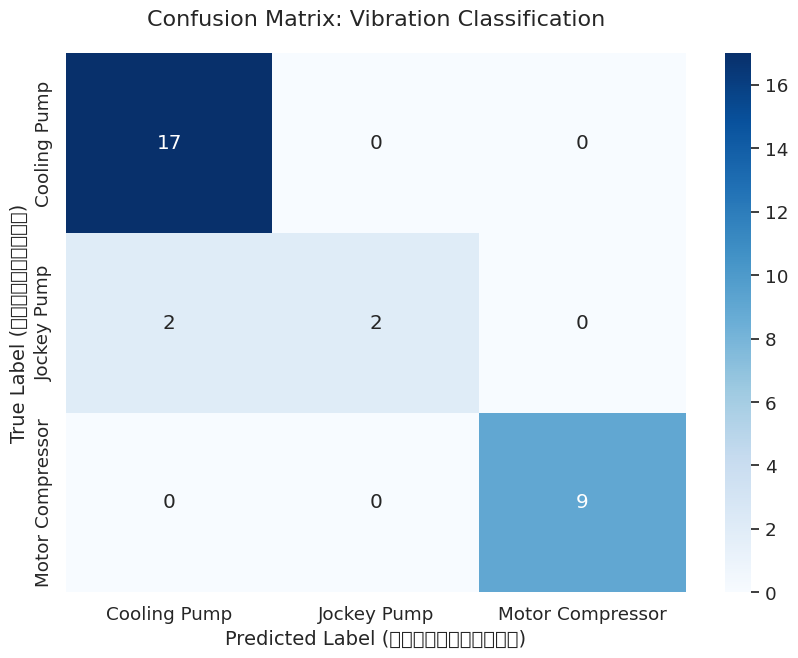

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. สร้าง Confusion Matrix จากค่าจริง (y_test) และค่าที่โมเดลทาย (y_pred)
y_pred = model.predict(X_test)
labels = sorted(y.unique()) # ดึงชื่อคลาสมาเรียงลำดับ
cm = confusion_matrix(y_test, y_pred, labels=labels)

# 2. ตั้งค่ารูปภาพ
plt.figure(figsize=(10, 7))
sns.set(font_scale=1.2) # ปรับขนาดตัวอักษร

# 3. วาด Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

# 4. ตกแต่งกราฟ
plt.title('Confusion Matrix: Vibration Classification', pad=20, fontsize=16)
plt.xlabel('Predicted Label (โมเดลทายว่า)', fontsize=14)
plt.ylabel('True Label (ค่าจริงคือ)', fontsize=14)
plt.show()

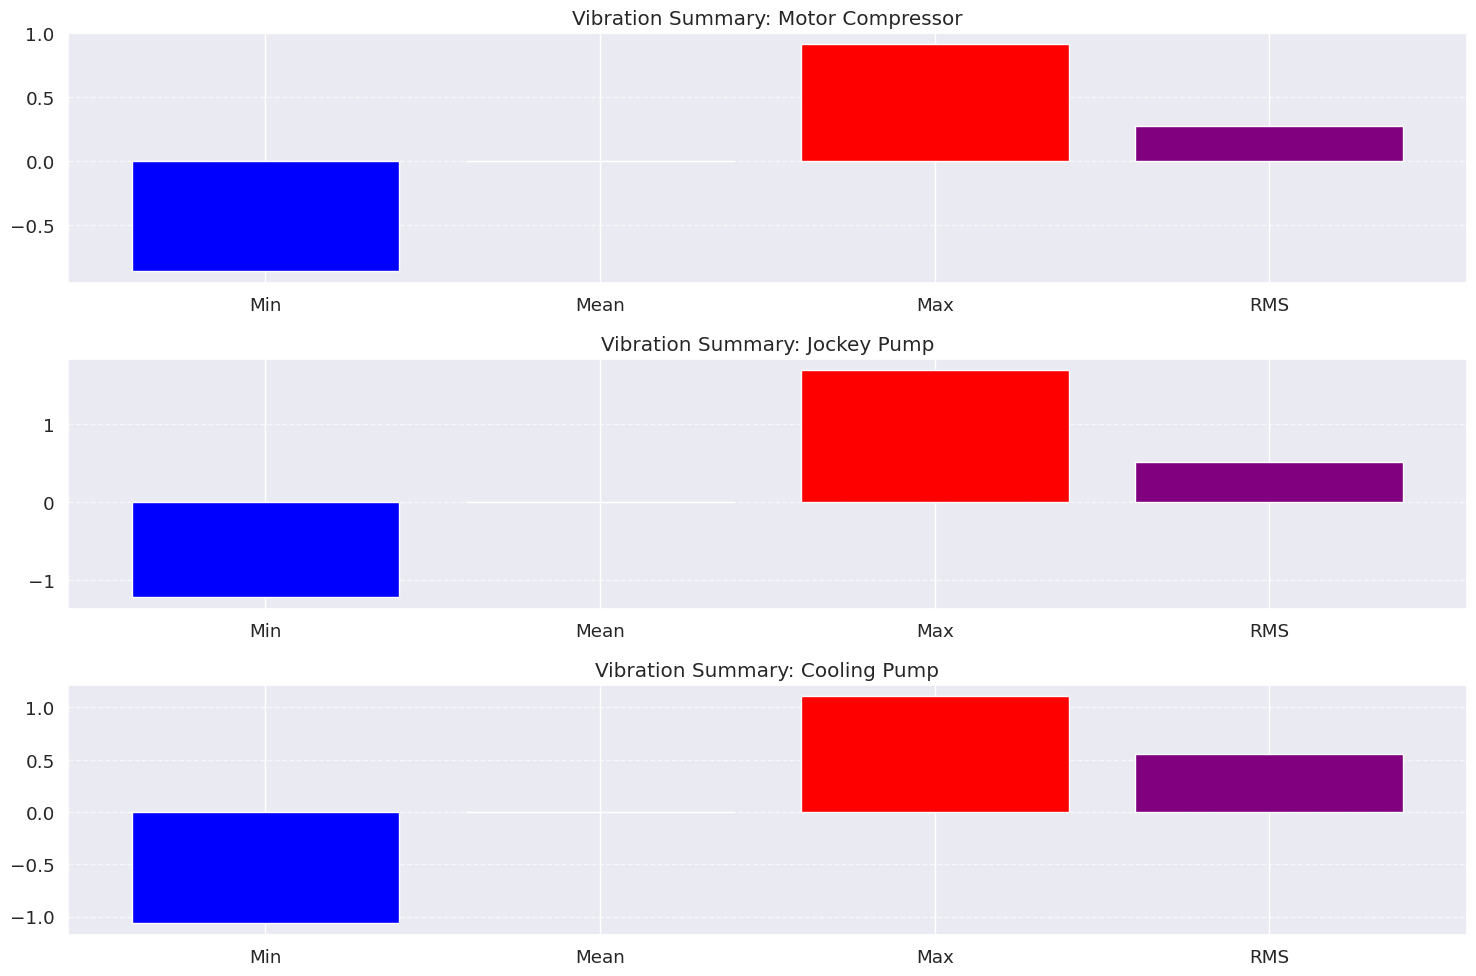

In [9]:
import matplotlib.pyplot as plt

# เลือกตัวอย่างสัญญาณจากแต่ละเครื่องจักรมาอย่างละ 1 ตัวอย่าง
unique_equip = df['target'].unique()
plt.figure(figsize=(15, 10))

for i, equip in enumerate(unique_equip):
    # ดึงข้อมูลจาก DataFrame ที่เราทำ Windowing ไว้แล้ว
    sample_signal = df[df['target'] == equip].iloc[0]

    plt.subplot(len(unique_equip), 1, i+1)
    # ในที่นี้เราอาจจะพลอตค่าสถิติ หรือถ้าเก็บค่า raw ไว้ก็นำมาพลอตได้
    # สมมติแสดงเป็นช่วงของแรงสั่นสะเทือน (Min-Max)
    plt.bar(['Min', 'Mean', 'Max', 'RMS'],
            [sample_signal['min'], sample_signal['mean'], sample_signal['max'], sample_signal['rms']],
            color=['blue', 'green', 'red', 'purple'])
    plt.title(f'Vibration Summary: {equip}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_474/1096749994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, palette='Set2')
/tmp/ipykernel_474/1096749994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, palette='Set2')
/tmp/ipykernel_474/1096749994.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=feature, data=df, palette='Set2')


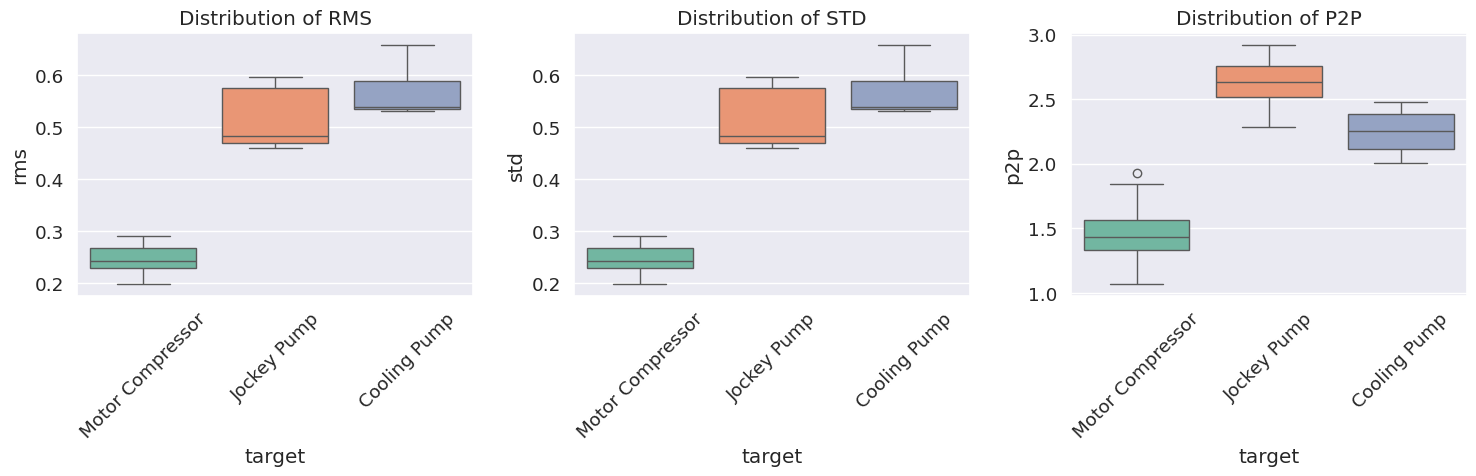

In [10]:
import seaborn as sns

# เลือกฟีเจอร์หลักๆ มาดูการกระจายตัว
features_to_plot = ['rms', 'std', 'p2p']
plt.figure(figsize=(15, 5))

for i, feature in enumerate(features_to_plot):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='target', y=feature, data=df, palette='Set2')
    plt.title(f'Distribution of {feature.upper()}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3657 (\N{THAI CHARACTER MAI THO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

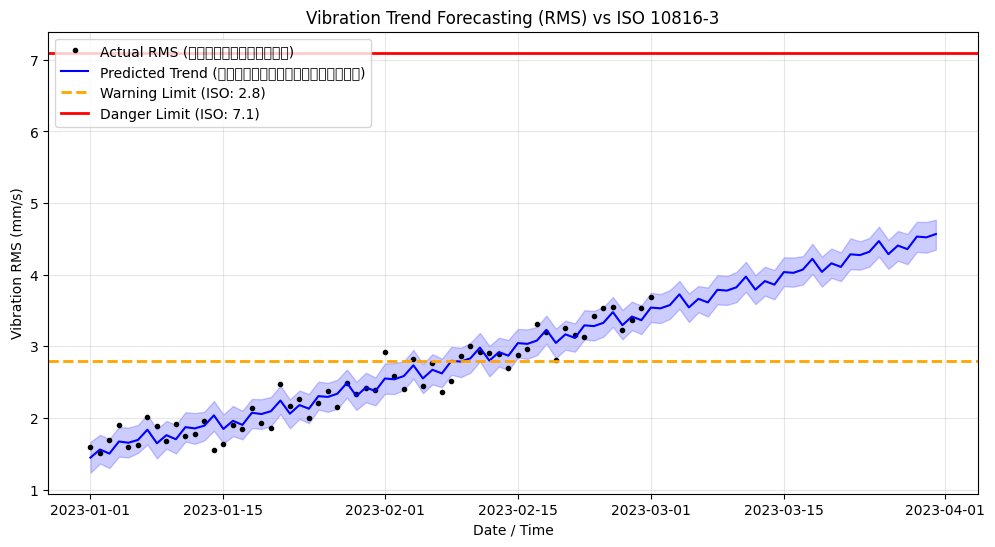

⚠️ แจ้งเตือน: แนวโน้มการสั่นสะเทือนจะเข้าสู่โซนเฝ้าระวัง (Warning) ในวันที่: 2023-02-10


In [5]:
# ติดตั้งไลบรารี prophet (หากยังไม่มี)
!pip install prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# ==========================================
# 1. จำลองการอ่านข้อมูลและเตรียมข้อมูล (Timestamp & Amplitude)
# ==========================================
# หมายเหตุ: ในการใช้งานจริง ให้ใช้ pd.read_csv อ่านไฟล์ .txt ของคุณ
# df = pd.read_csv('/content/drive/MyDrive/.../data.txt', sep='\s+', names=['timestamp', 'amplitude'])
# df['timestamp'] = pd.to_datetime(df['timestamp']) # แปลงเป็นรูปแบบเวลา

# --- สร้างข้อมูลจำลอง (เพื่อทดสอบรันโค้ด) ---
np.random.seed(42)
# จำลองข้อมูล 60 วันย้อนหลัง
dates = pd.date_range(start='2023-01-01', periods=60, freq='D')
# จำลองค่า RMS ที่มีแนวโน้มค่อยๆ สูงขึ้น (เสื่อมสภาพตามเวลา)
rms_values = np.linspace(1.5, 3.5, 60) + np.random.normal(0, 0.2, 60)

# สร้าง DataFrame ตามรูปแบบที่ Prophet ต้องการคือต้องมีคอลัมน์ 'ds' (เวลา) และ 'y' (ค่าที่ต้องการพยากรณ์)
df_trend = pd.DataFrame({
    'ds': dates,
    'y': rms_values
})

# ==========================================
# 2. สร้างและสอนโมเดลพยากรณ์ด้วย Prophet
# ==========================================
# สร้างโมเดล Prophet
model = Prophet(yearly_seasonality=False, daily_seasonality=False)

# สอนโมเดลด้วยข้อมูลในอดีต (60 วันที่ผ่านมา)
model.fit(df_trend)

# ==========================================
# 3. พยากรณ์แนวโน้มในอนาคต (Forecasting)
# ==========================================
# สร้างตารางเวลาสำหรับอนาคต (เช่น พยากรณ์ล่วงหน้า 30 วัน)
future_dates = model.make_future_dataframe(periods=30, freq='D')

# ให้โมเดลทำนายค่า RMS ในอนาคต
forecast = model.predict(future_dates)

# ==========================================
# 4. วาดกราฟแนวโน้ม และใส่เกณฑ์ ISO 10816-3
# ==========================================
# สมมติค่าเกณฑ์ ISO 10816-3 (Group 2, Flexible Foundation)
limit_warning = 2.8 # Zone C (สีส้ม - เฝ้าระวัง)
limit_danger = 7.1  # Zone D (สีแดง - อันตราย)

plt.figure(figsize=(12, 6))

# พลอตข้อมูลจริงในอดีต (จุดสีดำ)
plt.plot(df_trend['ds'], df_trend['y'], 'k.', label='Actual RMS (ข้อมูลในอดีต)')

# พลอตเส้นที่โมเดลพยากรณ์ (เส้นสีน้ำเงิน)
plt.plot(forecast['ds'], forecast['yhat'], 'b-', label='Predicted Trend (แนวโน้มที่พยากรณ์)')

# พลอตแถบความคลาดเคลื่อน (พื้นที่สีฟ้าอ่อน)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='blue', alpha=0.2)

# ตีเส้นขีดจำกัดตามมาตรฐาน ISO 10816-3
plt.axhline(y=limit_warning, color='orange', linestyle='--', linewidth=2, label=f'Warning Limit (ISO: {limit_warning})')
plt.axhline(y=limit_danger, color='red', linestyle='-', linewidth=2, label=f'Danger Limit (ISO: {limit_danger})')

plt.title('Vibration Trend Forecasting (RMS) vs ISO 10816-3')
plt.xlabel('Date / Time')
plt.ylabel('Vibration RMS (mm/s)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================
# 5. หาว่าเครื่องจักรจะพังเมื่อไหร่? (Time to Failure)
# ==========================================
# หาจุดแรกที่ค่าพยากรณ์แตะเส้น Warning
warning_hit = forecast[forecast['yhat'] >= limit_warning]
if not warning_hit.empty:
    date_warning = warning_hit.iloc[0]['ds'].date()
    print(f"⚠️ แจ้งเตือน: แนวโน้มการสั่นสะเทือนจะเข้าสู่โซนเฝ้าระวัง (Warning) ในวันที่: {date_warning}")
else:
    print("✅ ข่าวดี: ในระยะเวลาที่พยากรณ์ เครื่องจักรยังอยู่ในเกณฑ์ปกติ")

In [9]:
import os
import glob
import warnings
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from google.colab import drive

# ==========================================
# ปิดการแสดงผล Warning และ Log ที่ไม่จำเป็น
# ==========================================
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)
logging.getLogger('prophet').setLevel(logging.ERROR)

# ==========================================
# 1. เชื่อมต่อ Google Drive
# ==========================================
drive.mount('/content/drive', force_remount=True)

# ==========================================
# 2. ฟังก์ชันอ่านไฟล์ .txt และเตรียมข้อมูล RMS
# ==========================================
def load_and_prepare_data(folder_path):
    all_data = []
    txt_files = glob.glob(os.path.join(folder_path, '*.txt'))

    if not txt_files:
        print(f"❌ ไม่พบไฟล์ .txt ในโฟลเดอร์: {folder_path}")
        return pd.DataFrame()

    print(f"กำลังอ่านและประมวลผลไฟล์ .txt จำนวน {len(txt_files)} ไฟล์...")

    for file in txt_files:
        try:
            # แก้ไขข้อ 1: ใส่ r นำหน้า \s+ ป้องกัน SyntaxWarning
            df = pd.read_csv(file, sep=r'\s+', header=None, on_bad_lines='skip')

            if df.shape[1] >= 2:
                # ทำการ copy เพื่อป้องกันข้อมูลทับซ้อน
                df = df.iloc[:, [0, 1]].copy()
                df.columns = ['timestamp', 'amplitude']

                # แปลงให้เป็นเวลาและตัวเลขที่ถูกต้อง (ถ้าเจอข้อความแปลกๆ จะแปลงเป็น NaN)
                df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
                df['amplitude'] = pd.to_numeric(df['amplitude'], errors='coerce')

                # ลบแถวที่แปลงค่าไม่ได้ออก
                df.dropna(subset=['timestamp', 'amplitude'], inplace=True)

                if not df.empty:
                    all_data.append(df)
        except Exception:
            pass

    if not all_data:
        return pd.DataFrame()

    # นำข้อมูลทุกไฟล์มารวมกัน และเรียงตามเวลา
    full_df = pd.concat(all_data, ignore_index=True)
    full_df.sort_values('timestamp', inplace=True)

    # แก้ไขข้อ 2: เลือดยุบรวมเฉพาะคอลัมน์ Amplitude ป้องกัน ValueError timestamp ซ้ำ
    full_df.set_index('timestamp', inplace=True)
    rms_series = full_df['amplitude'].resample('1D').apply(lambda x: np.sqrt(np.mean(x**2)))

    # จัดรูปแบบตารางให้ Prophet ('ds' และ 'y')
    rms_df = rms_series.dropna().reset_index()
    rms_df.columns = ['ds', 'y']

    return rms_df

# ==========================================
# 3. ระบุ Path ของข้อมูล
# ==========================================
folder_path = '/content/drive/MyDrive/Predictive_Maintenance/data'
df = load_and_prepare_data(folder_path)

# ตรวจสอบว่ามีข้อมูลพร้อมรันโมเดลหรือไม่
if not df.empty and len(df) > 5:

    # ==========================================
    # 4. แบ่งข้อมูล Train / Test (ใช้ 80% แรกสอนโมเดล)
    # ==========================================
    train_size = int(len(df) * 0.8)
    train_df = df.iloc[:train_size]
    test_df = df.iloc[train_size:]

    # ==========================================
    # 5. สร้างและสอนโมเดล Prophet
    # ==========================================
    model = Prophet(yearly_seasonality=False, daily_seasonality=True)
    model.fit(train_df)

    # ==========================================
    # 6. พยากรณ์ และวิเคราะห์ความแม่นยำ
    # ==========================================
    future_dates = test_df[['ds']]
    forecast = model.predict(future_dates)

    y_true = test_df['y'].values
    y_pred = forecast['yhat'].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print("\n✅ ประมวลผลเสร็จสิ้น!")
    print("=== รายงานความแม่นยำของโมเดล (Model Evaluation) ===")
    print(f"MAE  (คลาดเคลื่อนเฉลี่ย): {mae:.3f} mm/s")
    print(f"RMSE (คลาดเคลื่อนถ่วงน้ำหนัก): {rmse:.3f} mm/s")
    print(f"MAPE (คลาดเคลื่อนเป็น %): {mape:.2f}%")
    print("====================================================\n")

    # ==========================================
    # 7. วาดกราฟผลลัพธ์
    # ==========================================
    limit_warning = 2.8
    limit_danger = 7.1

    plt.figure(figsize=(12, 6))

    plt.plot(train_df['ds'], train_df['y'], 'k.', label='Training Data (ข้อมูลในอดีต)')
    plt.plot(test_df['ds'], test_df['y'], 'g.', markersize=10, label='Actual Test Data (ความจริงที่เกิดขึ้น)')
    plt.plot(forecast['ds'], forecast['yhat'], 'b-', linewidth=2, label='Predicted Trend (เส้นพยากรณ์)')

    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='blue', alpha=0.2)

    plt.axhline(y=limit_warning, color='orange', linestyle='--', linewidth=2, label=f'Warning Limit (ISO: {limit_warning})')
    plt.axhline(y=limit_danger, color='red', linestyle='-', linewidth=2, label=f'Danger Limit (ISO: {limit_danger})')

    plt.axvline(x=train_df['ds'].iloc[-1], color='gray', linestyle=':', linewidth=2, label='Start of Forecast')

    plt.title('Vibration Trend Forecasting (RMS) vs ISO 10816-3')
    plt.xlabel('Date / Time')
    plt.ylabel('Vibration RMS (mm/s)')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("\n❌ ข้อมูลในไฟล์อาจจะไม่สมบูรณ์ หรือมีจุดเวลาน้อยเกินไป (ต้องการอย่างน้อย 5 จุด)")

Mounted at /content/drive
กำลังอ่านและประมวลผลไฟล์ .txt จำนวน 9 ไฟล์...

❌ ข้อมูลในไฟล์อาจจะไม่สมบูรณ์ หรือมีจุดเวลาน้อยเกินไป (ต้องการอย่างน้อย 5 จุด)


--- เริ่มต้นระบบวิเคราะห์ความสั่นสะเทือน (Multi-Machine) ---
✅ พบข้อมูลทั้งหมด 9 ไฟล์... กำลังสกัดข้อมูล
  - สกัดข้อมูลสำเร็จ: A_CH-06 A_NAA_1490 | Jun 2024 | RMS: 9.21
  - สกัดข้อมูลสำเร็จ: A_CH-06 A_NAA_1490 | Oct 2024 | RMS: 4.93
  - สกัดข้อมูลสำเร็จ: A_CH-06 A_NAA_1490 | Sep 2024 | RMS: 39.56
  - สกัดข้อมูลสำเร็จ: A_Cooling Pump OAH 02_M1H_1480 | Jun 2024 | RMS: 9.11
  - สกัดข้อมูลสำเร็จ: A_Cooling Pump OAH 02_M1H_1480 | Oct 2024 | RMS: 5.81
  - สกัดข้อมูลสำเร็จ: A_Cooling Pump OAH 02_M1H_1480 | Sep 2024 | RMS: 211.89
  - สกัดข้อมูลสำเร็จ: A_Jockey pump_M1A_2925 | Jun 2024 | RMS: 7.27
  - สกัดข้อมูลสำเร็จ: A_Jockey pump_M1A_2925 | Oct 2024 | RMS: 6.83
  - สกัดข้อมูลสำเร็จ: A_Jockey pump_M1A_2925 | Sep 2024 | RMS: 8.26

🔍 พบเครื่องจักรทั้งหมด 3 ตัว: A_CH-06 A_NAA_1490, A_Cooling Pump OAH 02_M1H_1480, A_Jockey pump_M1A_2925

❌ [อันตราย] A_CH-06 A_NAA_1490: ค่าความสั่นเกินเกณฑ์ Danger ไปแล้ว!


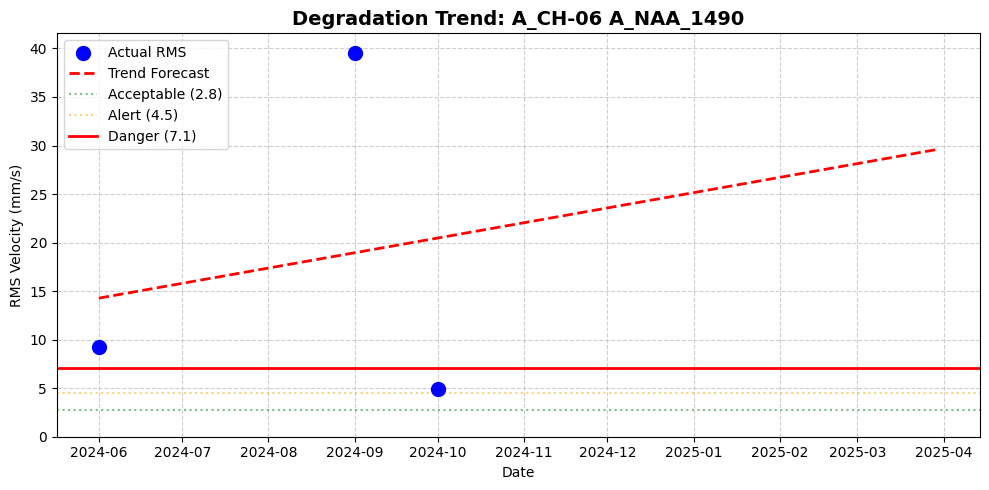


❌ [อันตราย] A_Cooling Pump OAH 02_M1H_1480: ค่าความสั่นเกินเกณฑ์ Danger ไปแล้ว!


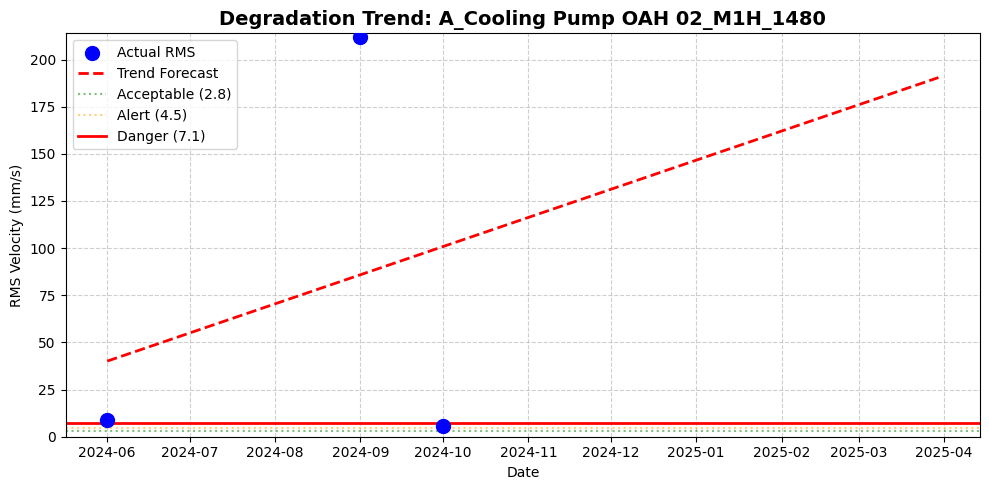


❌ [อันตราย] A_Jockey pump_M1A_2925: ค่าความสั่นเกินเกณฑ์ Danger ไปแล้ว!


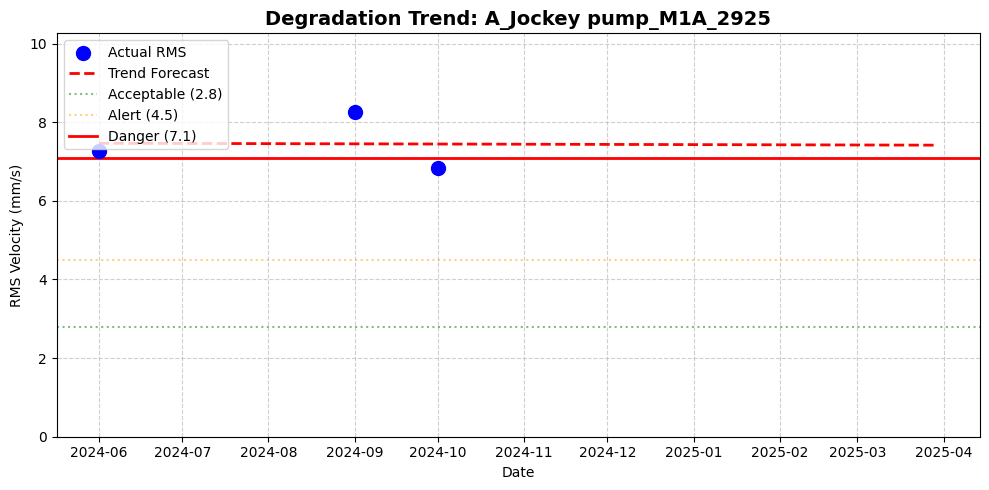


--- สิ้นสุดการทำงาน ---


In [21]:
import os
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy import integrate
from scipy.signal import detrend, butter, filtfilt
from sklearn.linear_model import LinearRegression

# ==========================================
# PART 1: CONFIGURATION
# ==========================================
# 📂 Path โฟลเดอร์ที่เก็บไฟล์ข้อมูล
DATA_FOLDER_PATH = "/content/drive/MyDrive/Predictive_Maintenance/data"
FILE_EXTENSION = "*.txt"

# ⚙️ ISO 10816-3 Thresholds (mm/s RMS)
ISO_DANGER_THRESHOLD = 7.1
ISO_ALERT_THRESHOLD = 4.5
ISO_ACCEPTABLE_THRESHOLD = 2.8

# ==========================================
# PART 2: SIGNAL PROCESSING
# ==========================================
def highpass_filter(data, cutoff_hz, fs_hz, order=4):
    nyquist = 0.5 * fs_hz
    normal_cutoff = cutoff_hz / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, data)
    return y

def load_file_raw(path):
    """อ่านไฟล์และบังคับแปลงข้อมูลเป็นตัวเลข (ลบบรรทัดที่เป็น Text ขยะทิ้ง)"""
    # 1. อ่านไฟล์แบบข้ามบรรทัดที่พัง
    df = pd.read_csv(path, sep=r"\s+", header=None, skiprows=20,
                     usecols=[0, 1], on_bad_lines='skip', engine='python')
    df.columns = ['time_ms', 'acc_g']

    # 2. บังคับแปลงคอลัมน์ให้เป็นตัวเลข (ถ้าเป็นตัวหนังสือจะถูกแปลงเป็น NaN)
    df['time_ms'] = pd.to_numeric(df['time_ms'], errors='coerce')
    df['acc_g'] = pd.to_numeric(df['acc_g'], errors='coerce')

    # 3. ลบบรรทัดที่มีค่า NaN (ข้อมูลเสีย) ทิ้งไป เพื่อให้คำนวณต่อได้
    df = df.dropna().reset_index(drop=True)

    return df

def extract_rms_velocity(df):
    t = df['time_ms'].values / 1000

    diff_t = np.diff(t)
    dt = np.mean(diff_t[diff_t > 0])
    if dt == 0 or np.isnan(dt): return 0
    fs = 1.0 / dt

    a = df['acc_g'].values * 9.81
    a = a - np.mean(a)
    a = detrend(a)

    a_filtered = highpass_filter(a, cutoff_hz=10.0, fs_hz=fs)
    v = integrate.cumulative_trapezoid(a_filtered, t, initial=0)
    v = v * 1000  # เป็น mm/s
    v_filtered = highpass_filter(v, cutoff_hz=10.0, fs_hz=fs)

    rms = np.sqrt(np.mean(v_filtered**2))
    return rms

# ==========================================
# PART 3: FILENAME PARSER (แยกเครื่องจักรและเวลา)
# ==========================================
def parse_filename(filename):
    """
    แยกชื่อเครื่องจักร และ วันเวลา ออกจากชื่อไฟล์
    เช่น: 'A_CH-06 A_NAA_1490__Jun24.txt'
    -> Machine: 'A_CH-06 A_NAA_1490', Date: 2024-06-01
    """
    try:
        # Regex ดึง [ชื่อเครื่องจักร]_[เดือน3ตัวอักษร][ปี2หลัก].txt
        match = re.search(r'^(.*?)_*([A-Za-z]{3})(\d{2})\.txt$', filename, re.IGNORECASE)

        if match:
            machine_name = match.group(1).strip('_') # ชื่อเครื่องจักร
            date_str = match.group(2) + match.group(3) # เช่น Jun24
            timestamp = datetime.strptime(date_str, '%b%y') # แปลงเป็นวันที่
            return machine_name, timestamp
        else:
            return None, None
    except Exception as e:
        print(f"Error parsing filename {filename}: {e}")
        return None, None

# ==========================================
# PART 4: DATASET CREATION
# ==========================================
def create_dataset(folder_path, extension):
    search_pattern = os.path.join(folder_path, extension)
    all_files = sorted(glob.glob(search_pattern))

    if len(all_files) == 0:
        raise Exception("⚠️ ไม่พบไฟล์ใดๆ ในโฟลเดอร์ กรุณาเช็ค Path")

    print(f"✅ พบข้อมูลทั้งหมด {len(all_files)} ไฟล์... กำลังสกัดข้อมูล")

    dataset = []
    for file_path in all_files:
        filename = os.path.basename(file_path)

        machine_name, timestamp = parse_filename(filename)
        if timestamp is None:
            print(f"⚠️ ข้ามไฟล์ {filename} (อ่านรูปแบบชื่อไม่สำเร็จ)")
            continue

        try:
            raw_df = load_file_raw(file_path)
            rms_v = extract_rms_velocity(raw_df)

            dataset.append({
                'Machine': machine_name,
                'Timestamp': timestamp,
                'RMS': rms_v
            })
            print(f"  - สกัดข้อมูลสำเร็จ: {machine_name} | {timestamp.strftime('%b %Y')} | RMS: {rms_v:.2f}")
        except Exception as e:
            print(f"❌ Error ไฟล์ {filename}: {e}")

    ts_df = pd.DataFrame(dataset)
    return ts_df

# ==========================================
# PART 5: TREND MODELING & PLOTTING
# ==========================================
def analyze_and_plot_machine(df_machine, machine_name, forecast_days=180):
    df = df_machine.sort_values(by='Timestamp').copy()

    if len(df) < 2:
        print(f"\n⚠️ ข้าม {machine_name}: มีข้อมูลน้อยเกินไป ({len(df)} ไฟล์) ไม่สามารถสร้างแนวโน้มได้")
        return

    # แปลงเวลาเป็นตัวเลขจำนวนวัน
    df['Days'] = (df['Timestamp'] - df['Timestamp'].min()).dt.days

    X = df[['Days']].values
    y = df['RMS'].values

    # ใช้ Linear Regression (เส้นตรง) เหมาะกับข้อมูลน้อยๆ (เช่น 3 จุด)
    model = LinearRegression()
    model.fit(X, y)

    # พยากรณ์ไปข้างหน้า
    last_day = df['Days'].max()
    X_future = np.arange(0, last_day + forecast_days + 1).reshape(-1, 1)
    y_pred = model.predict(X_future)
    future_dates = [df['Timestamp'].min() + timedelta(days=int(d)) for d in X_future.flatten()]

    # พล็อตกราฟ
    plt.figure(figsize=(10, 5))
    plt.scatter(df['Timestamp'], df['RMS'], color='blue', label='Actual RMS', s=100, zorder=5)
    plt.plot(future_dates, y_pred, color='red', linestyle='--', linewidth=2, label='Trend Forecast')

    # ขีดเส้น ISO
    plt.axhline(y=ISO_ACCEPTABLE_THRESHOLD, color='green', linestyle=':', alpha=0.5, label='Acceptable (2.8)')
    plt.axhline(y=ISO_ALERT_THRESHOLD, color='orange', linestyle=':', alpha=0.5, label='Alert (4.5)')
    plt.axhline(y=ISO_DANGER_THRESHOLD, color='red', linestyle='-', linewidth=2, label='Danger (7.1)')

    plt.title(f"Degradation Trend: {machine_name}", fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('RMS Velocity (mm/s)')
    plt.ylim(0, max(10, df['RMS'].max() + 2))
    plt.legend(loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)

    # เช็คว่ากราฟตัดเส้น Danger ไหม
    failure_idx = np.where(y_pred >= ISO_DANGER_THRESHOLD)[0]
    if len(failure_idx) > 0:
        predicted_date = future_dates[failure_idx[0]]
        if predicted_date > df['Timestamp'].max():
            days_left = (predicted_date - df['Timestamp'].max()).days
            plt.axvline(x=predicted_date, color='black', linestyle='-.')
            plt.plot(predicted_date, ISO_DANGER_THRESHOLD, marker='X', color='black', markersize=12)
            print(f"\n🚨 [เตือนภัย] {machine_name}: คาดว่าจะแตะ Danger Zone วันที่ {predicted_date.strftime('%Y-%m-%d')} (อีกประมาณ {days_left} วัน)")
        else:
             print(f"\n❌ [อันตราย] {machine_name}: ค่าความสั่นเกินเกณฑ์ Danger ไปแล้ว!")
    else:
        print(f"\n✅ [ปลอดภัย] {machine_name}: แนวโน้มในอีก {forecast_days} วัน ยังอยู่ในเกณฑ์ปลอดภัย")

    plt.tight_layout()
    plt.show()

# ==========================================
# MAIN EXECUTION
# ==========================================
print("--- เริ่มต้นระบบวิเคราะห์ความสั่นสะเทือน (Multi-Machine) ---")

try:
    # 1. สร้างฐานข้อมูลรวมจากทุกไฟล์
    master_df = create_dataset(DATA_FOLDER_PATH, FILE_EXTENSION)

    if not master_df.empty:
        # 2. หารายชื่อเครื่องจักรทั้งหมดที่มีในโฟลเดอร์
        unique_machines = master_df['Machine'].unique()
        print(f"\n🔍 พบเครื่องจักรทั้งหมด {len(unique_machines)} ตัว: {', '.join(unique_machines)}")

        # 3. วนลูปสร้างกราฟทีละเครื่อง
        for machine in unique_machines:
            machine_data = master_df[master_df['Machine'] == machine]
            analyze_and_plot_machine(machine_data, machine_name=machine, forecast_days=180) # พยากรณ์ล่วงหน้า 6 เดือน

except Exception as e:
    print(f"\n❌ ระบบขัดข้อง: {e}")

print("\n--- สิ้นสุดการทำงาน ---")